In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
csv_path = Path("/scratch/jma819/CaliAli_linearTrackData/mouse_velocity_binned_window20_20260529_124155.csv")

mouse_velocity_binned_df = pd.read_csv(csv_path)

print(mouse_velocity_binned_df.shape)
mouse_velocity_binned_df.head()

(45, 8)


,velocity_bin,mean_events_per_second,sem_events_per_second,n_windows,mean_velocity,mouse,speed_bin_low,speed_bin_high
0,0-0.5,0.023830,0.000042,70697,0.050305,m311,0.0,0.5
1,0.5-2,0.029504,0.000070,34595,1.268614,m311,0.5,2.0
2,2-5,0.030256,0.000052,60716,3.328912,m311,2.0,5.0
3,5-10,0.028831,0.000067,30985,6.887154,m311,5.0,10.0
4,10+,0.029100,0.000046,70627,27.091131,m311,10.0,inf


In [3]:
mouse_velocity_binned_df

,velocity_bin,mean_events_per_second,sem_events_per_second,n_windows,mean_velocity,mouse,speed_bin_low,speed_bin_high
0,0-0.5,0.023830,0.000042,70697,0.050305,m311,0.0,0.5
1,0.5-2,0.029504,0.000070,34595,1.268614,m311,0.5,2.0
2,2-5,0.030256,0.000052,60716,3.328912,m311,2.0,5.0
3,5-10,0.028831,0.000067,30985,6.887154,m311,5.0,10.0
4,10+,0.029100,0.000046,70627,27.091131,m311,10.0,inf
5,0-0.5,0.019267,0.000042,40082,0.068915,m326,0.0,0.5
6,0.5-2,0.020782,0.000048,32281,1.298045,m326,0.5,2.0
7,2-5,0.020717,0.000035,57301,3.241103,m326,2.0,5.0
8,5-10,0.020699,0.000061,20141,6.833399,m326,5.0,10.0
9,10+,0.020542,0.000027,87101,34.236225,m326,10.0,inf


/scratch/jma819/CaliAli_linearTrackData/WT_vs_A636T_event_rate_across_velocity_bins_labeled.pdf


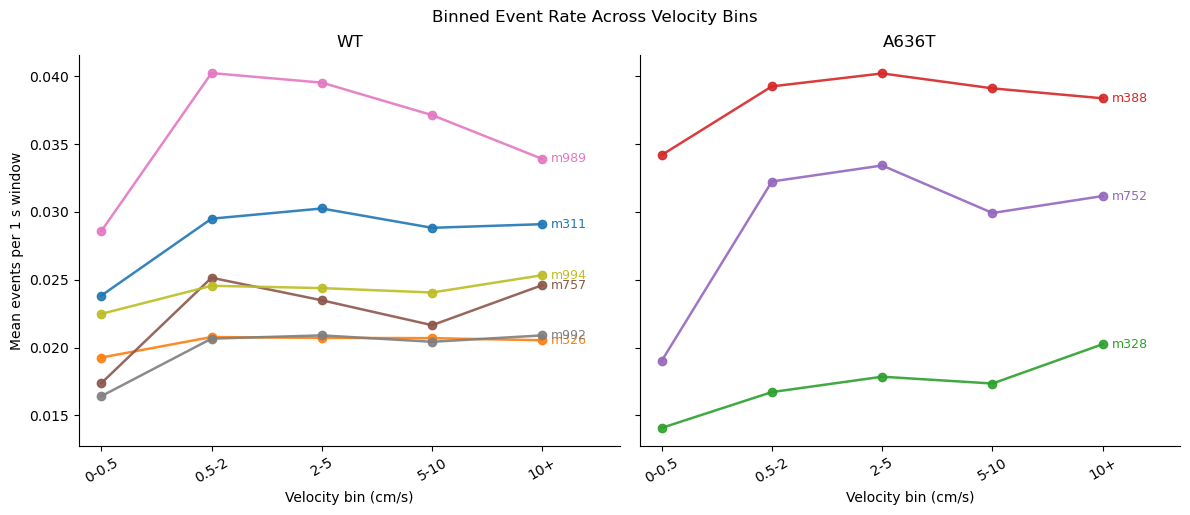

In [6]:
# mice are
# WT: [992, 994, 989, 757, 326, 311]
# A636T mutant: [752, 328, 388]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

wt_ids = [992, 994, 989, 757, 326, 311]
mut_ids = [752, 328, 388]

wt_mice = [f"m{x}" for x in wt_ids]
mut_mice = [f"m{x}" for x in mut_ids]

bin_order = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]

def format_bin_label(lo, hi):
    if np.isinf(hi):
        return f"{lo:g}+"
    return f"{lo:g}-{hi:g}"

bin_labels = [format_bin_label(lo, hi) for lo, hi in bin_order]
bin_to_x = {b: i for i, b in enumerate(bin_order)}

plot_df = mouse_velocity_binned_df.copy()
plot_df["bin_tuple"] = list(zip(plot_df["speed_bin_low"], plot_df["speed_bin_high"]))
plot_df["x"] = plot_df["bin_tuple"].map(bin_to_x)

all_mice = sorted(plot_df["mouse"].unique())
palette = plt.cm.tab10(np.linspace(0, 1, max(len(all_mice), 10)))
mouse_color_map = {mouse: palette[i % len(palette)] for i, mouse in enumerate(all_mice)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, mice, title in [
    (axes[0], wt_mice, "WT"),
    (axes[1], mut_mice, "A636T"),
]:
    sub_df = plot_df.loc[plot_df["mouse"].isin(mice)].copy()

    for mouse in sorted(sub_df["mouse"].unique()):
        sub = sub_df.loc[sub_df["mouse"] == mouse].sort_values("x")
        color = mouse_color_map[mouse]

        ax.plot(
            sub["x"],
            sub["mean_events_per_second"],
            marker="o",
            linewidth=1.8,
            markersize=6,
            alpha=0.9,
            color=color,
            label=mouse,
        )

        # label at the last point
        last_x = sub["x"].iloc[-1]
        last_y = sub["mean_events_per_second"].iloc[-1]
        ax.text(
            last_x + 0.08,
            last_y,
            mouse,
            color=color,
            fontsize=9,
            va="center",
        )

    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_labels, rotation=30)
    ax.set_xlim(-0.2, len(bin_order) - 1 + 0.7)
    ax.set_xlabel("Velocity bin (cm/s)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean events per 1 s window")
fig.suptitle("Binned Event Rate Across Velocity Bins", y=1.02)

plt.tight_layout()

save_dir = Path("/scratch/jma819/CaliAli_linearTrackData")
pdf_path = save_dir / "WT_vs_A636T_event_rate_across_velocity_bins_labeled.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(pdf_path)
plt.show()



/scratch/jma819/CaliAli_linearTrackData/WT_vs_A636T_event_rate_across_velocity_bins_group_mean_sem_errorbars.pdf


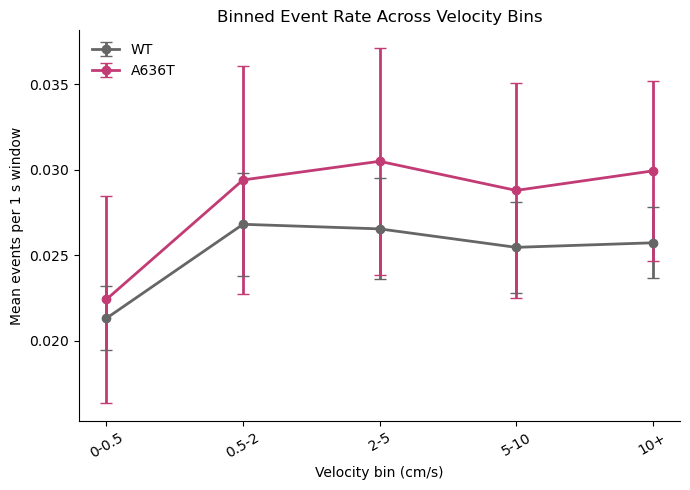

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# genotype groups
wt_ids = [992, 994, 989, 757, 326, 311]
mut_ids = [752, 328, 388]

wt_mice = [f"m{x}" for x in wt_ids]
mut_mice = [f"m{x}" for x in mut_ids]

bin_order = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]

def format_bin_label(lo, hi):
    if np.isinf(hi):
        return f"{lo:g}+"
    return f"{lo:g}-{hi:g}"

bin_labels = [format_bin_label(lo, hi) for lo, hi in bin_order]
bin_to_x = {b: i for i, b in enumerate(bin_order)}

plot_df = mouse_velocity_binned_df.copy()
plot_df["bin_tuple"] = list(zip(plot_df["speed_bin_low"], plot_df["speed_bin_high"]))
plot_df["x"] = plot_df["bin_tuple"].map(bin_to_x)

plot_df["genotype"] = pd.Series(pd.NA, index=plot_df.index, dtype="object")
plot_df.loc[plot_df["mouse"].isin(wt_mice), "genotype"] = "WT"
plot_df.loc[plot_df["mouse"].isin(mut_mice), "genotype"] = "A636T"
plot_df = plot_df.dropna(subset=["genotype"]).copy()

group_summary_df = (
    plot_df
    .groupby(["genotype", "speed_bin_low", "speed_bin_high", "x"], as_index=False)
    .agg(
        mean_events_per_second=("mean_events_per_second", "mean"),
        sem_events_per_second=("mean_events_per_second", "sem"),
        n_mice=("mouse", "nunique"),
    )
)

fig, ax = plt.subplots(figsize=(7, 5))

colors = {"WT": "#666666", "A636T": "#c23b75"}

for genotype in ["WT", "A636T"]:
    sub = (
        group_summary_df.loc[group_summary_df["genotype"] == genotype]
        .sort_values("x")
    )

    x = sub["x"].to_numpy()
    y = sub["mean_events_per_second"].to_numpy()
    sem = sub["sem_events_per_second"].to_numpy()

    ax.errorbar(
        x,
        y,
        yerr=sem,
        marker="o",
        linewidth=2,
        markersize=6,
        capsize=4,
        color=colors[genotype],
        label=genotype,
    )

ax.set_xticks(range(len(bin_order)))
ax.set_xticklabels(bin_labels, rotation=30)
ax.set_xlabel("Velocity bin (cm/s)")
ax.set_ylabel("Mean events per 1 s window")
ax.set_title("Binned Event Rate Across Velocity Bins")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()

save_dir = Path("/scratch/jma819/CaliAli_linearTrackData")
pdf_path = save_dir / "WT_vs_A636T_event_rate_across_velocity_bins_group_mean_sem_errorbars.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(pdf_path)
plt.show()


